# Example-11: Twiss from invariant fit (coupled)

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# In this example coupled twiss parameters are estimated from (linear) invariant fit

# Given (filtered) TbT data at each monitor location, twiss parameters at each probed monitor are estimated using x & y signals
# Other monitors are used to compute momentum at the probed monitor using model (or measured) transport matrix
# Using coordinates and momenta linear invariants are fitted
# Known invariant values can be passed, else both invariant values and twiss parameters are fitted
# Fit objective is ((jx(qx, px, qy, py; beta) - ix)**2 + (jy(qx, px, qy, py; beta) - iy)**2).sqrt()
# Or ((jx(qx, px, qy, py; beta) - ix)**2 * (jy(qx, px, qy, py; beta) - iy)**2).sqrt() (default)
# Where, for coupled case, beta = (n11, n33, n21, n43, n13, n31, n14, and n41) and ix & iy are invariant values (can be fixed on input or estimated)

# Fitting is performed using nonlinear least squares
# Note, fitting is bootstrapped (signals are randomly sampled with replacement)
# The result is returned for each sample (values and errors) at each monitor location (beta or beta and invariants)
# Processing (filtering and weighting) is then performed over samples for each monitor location
# Ones invariants are estimated, fit can be performed with fixed invariants (this can improve result quality in some cases)

# Here, random normal & skew thin quadrupole errors are introduced are twiss estimation is performed using amplitude & phase data
# These estimations are compared with fitted values

# Note, in this example unfiltered TbT data is used
# Note, for computation of momenta at the probed monitor, only the next monitor is used
# Methods using several monitors are also avaliable

In [4]:
# Set model with errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 0.5E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

4.198100746e-07, 1.397551577e-19
1.375156769e-07, 3.827953636e-19



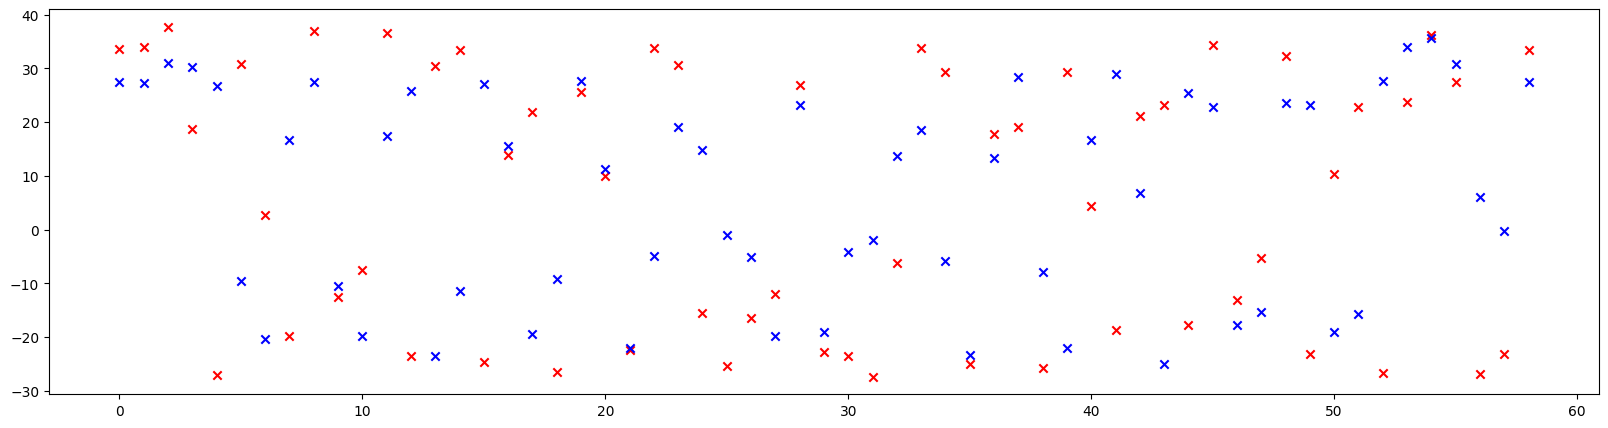

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(1.520498602253e+02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

In [6]:
# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0][model.monitor_index]
N33 = model.out_normal[:, 2, 2][model.monitor_index]
N21 = model.out_normal[:, 1, 0][model.monitor_index]
N43 = model.out_normal[:, 3, 2][model.monitor_index]
N13 = model.out_normal[:, 0, 2][model.monitor_index]
N31 = model.out_normal[:, 2, 0][model.monitor_index]
N14 = model.out_normal[:, 0, 3][model.monitor_index]
N41 = model.out_normal[:, 3, 0][model.monitor_index]

# Using eight free elements other elements of normalization matrix can be computed from symplectic condition
# Note, N12 and N34 are fixed to zero values

from harmonica.parameterization import parametric_normal
print(torch.allclose(model.out_normal[model.monitor_index], torch.stack([parametric_normal(*free) for free in torch.stack([N11, N33, N21, N43, N13, N31, N14, N41]).T])))

True


In [7]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(X)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.573615369
nux= 0.573615346, sigma_nux=1.06823985e-07, error_nux=2.22672286e-08


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nux={abs(mqy - nuy).item():12.9}')

# Estimate amplitude & phase

d = Decomposition(Y)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.614751728
nuy= 0.614751722, sigma_nuy=1.70458941e-07, error_nux=6.02006955e-09


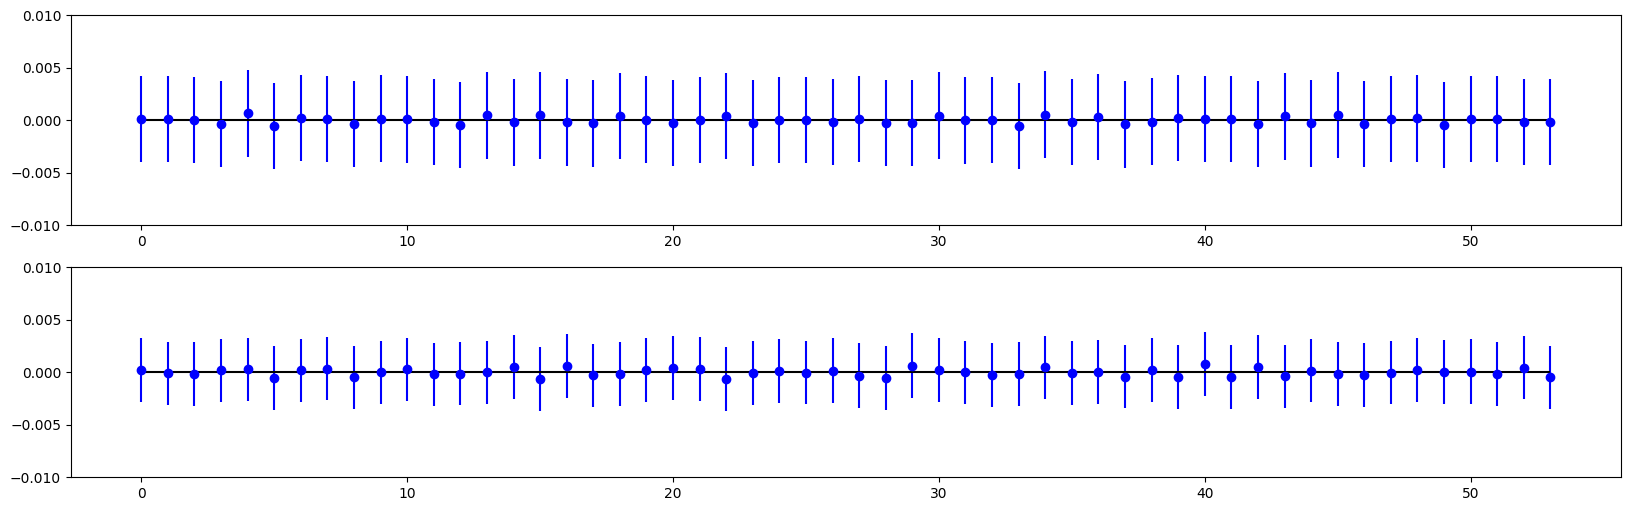

In [10]:
# Set table

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy,
    x=X.data,
    y=Y.data,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

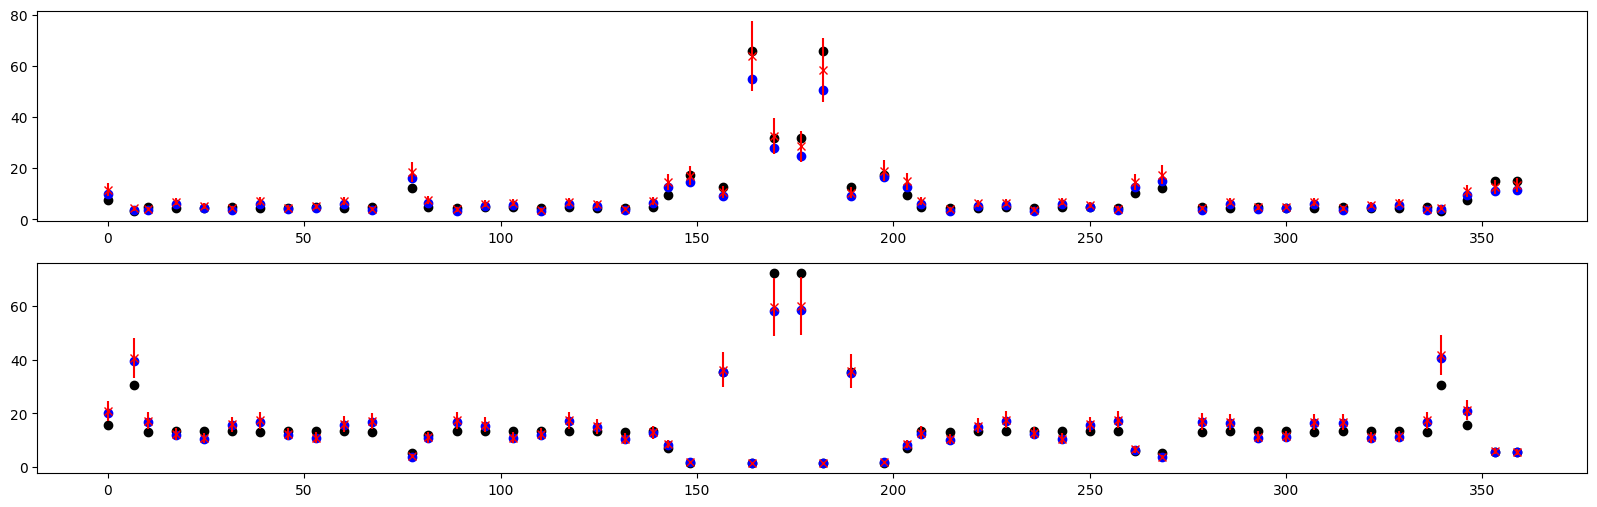

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)



In [11]:
# Estimate twiss from amplitude

twiss = Twiss(model, table, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_1 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_1 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print()

print(error_y)
print(error_y_1)
print()

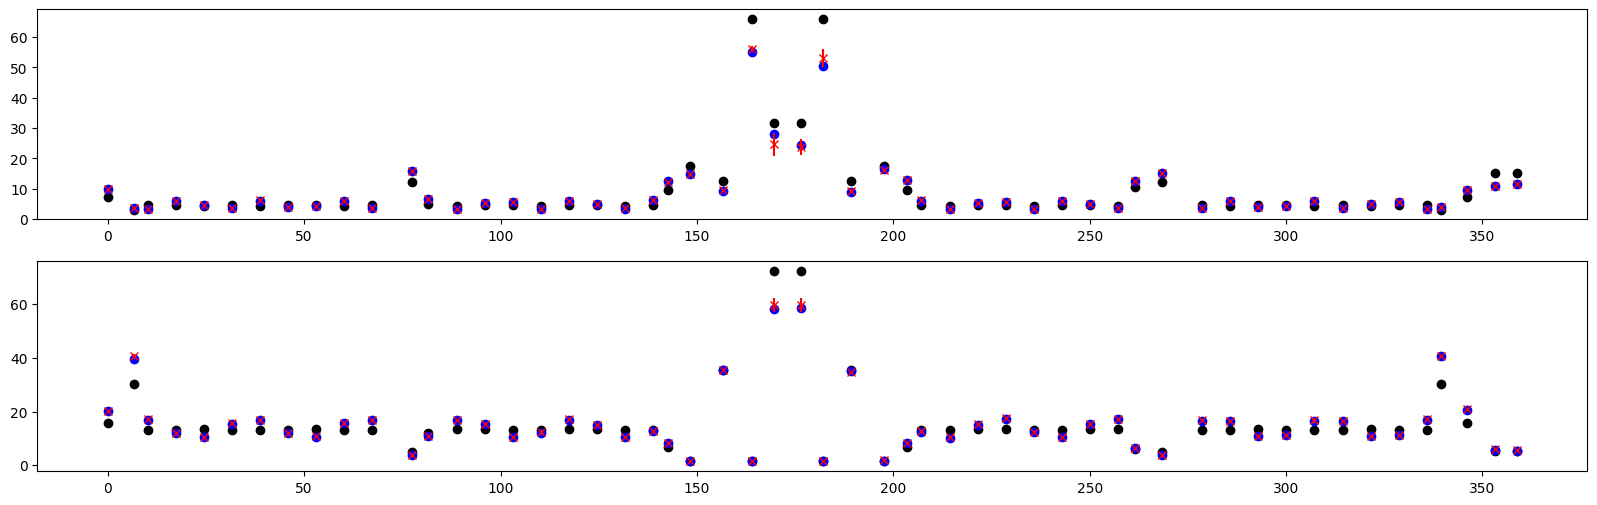

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)
tensor(1.002231996922e+01, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)
tensor(8.906506510477e+00, dtype=torch.float64)



In [12]:
# Estimate twiss from phase

twiss = Twiss(model, table, limit=4)
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='x', mask=mask_x, weight=True)
twiss.process_twiss(plane='y', mask=mask_y, weight=True)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.bx[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.by[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_2 = (cs_bx[model.monitor_index] - twiss.bx[model.monitor_index]).abs().sum()
error_y_2 = (cs_by[model.monitor_index] - twiss.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print()

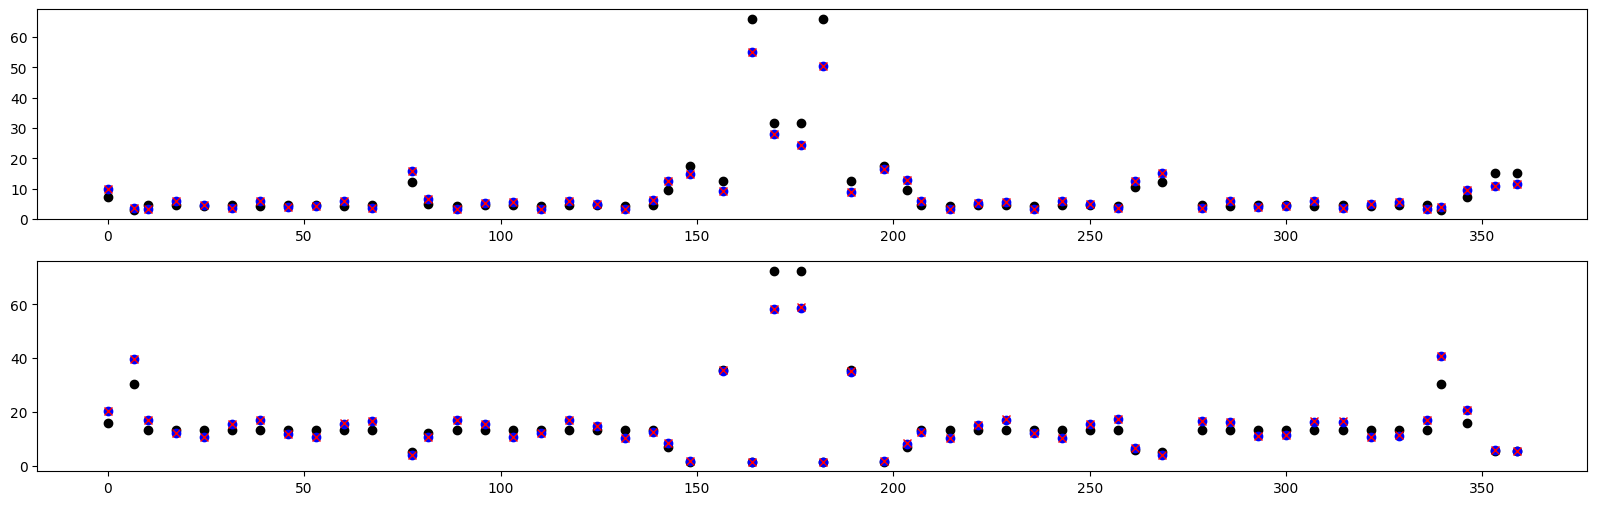

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)
tensor(1.002231996922e+01, dtype=torch.float64)
tensor(1.397734203849e-01, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)
tensor(8.906506510477e+00, dtype=torch.float64)
tensor(4.010454219395e+00, dtype=torch.float64)



In [13]:
# Estimate twiss from amplitude (corrected action)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_3 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_3 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print()

In [14]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 512 random samples)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='pair',    # -- momenta computation method
                                 limit=1,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=512,        # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=12,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag
print(data.shape)

torch.Size([54, 2, 10, 512])
CPU times: user 1min 16s, sys: 3.26 s, total: 1min 19s
Wall time: 1min 48s


In [15]:
# Process fitted invariants

ix = data[:, 0, 0]
iy = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

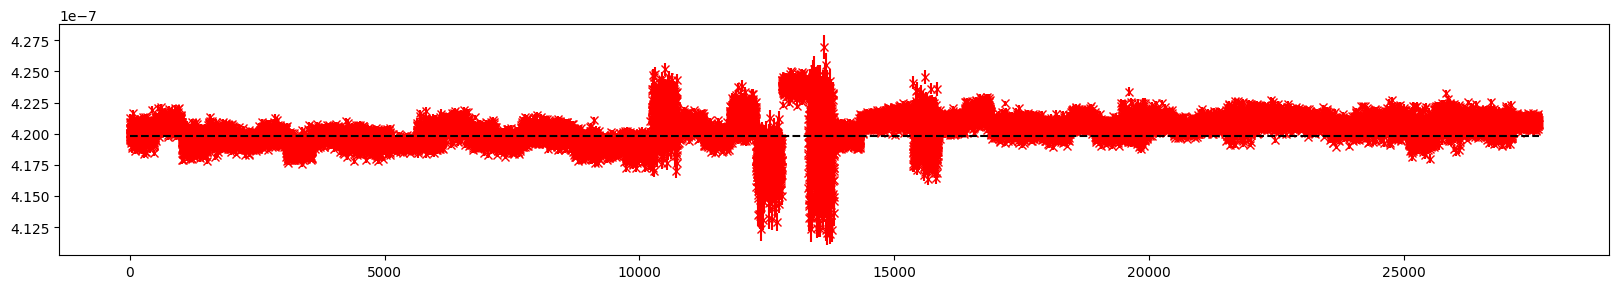

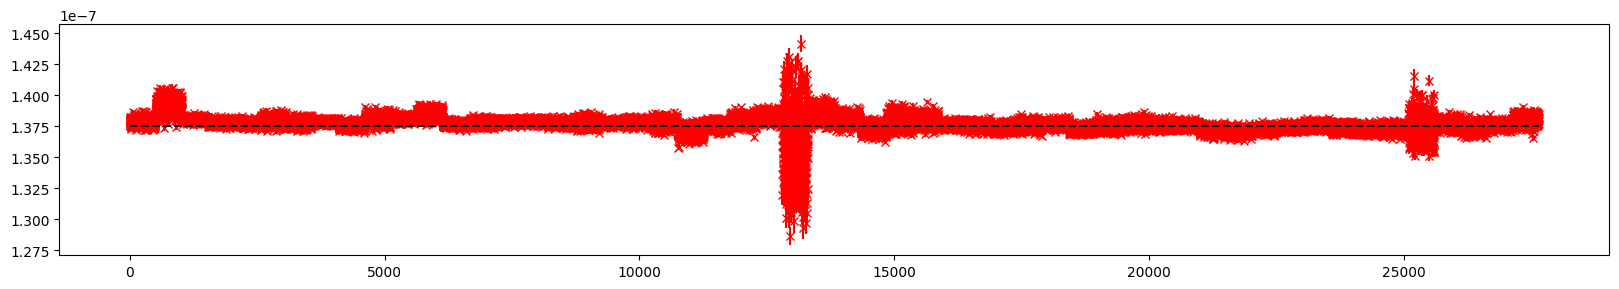

In [16]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*512), ix.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_x, 0, 54*512, linestyles='dashed', color='black',  zorder=1)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54*512), iy.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(action_y, 0, 54*512, linestyles='dashed', color='black',  zorder=1)
plt.show()

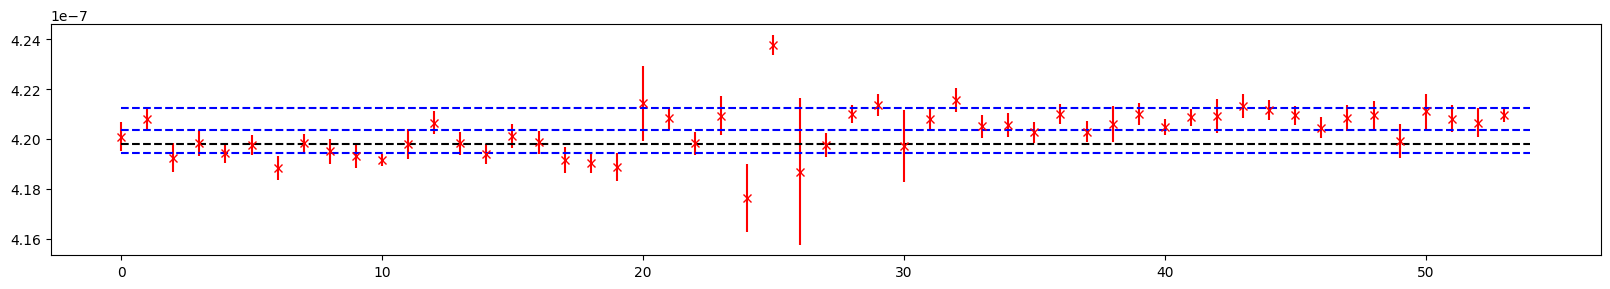

tensor(4.198100745916e-07, dtype=torch.float64)
tensor(4.203522224352e-07, dtype=torch.float64)
tensor(9.103405262857e-10, dtype=torch.float64)



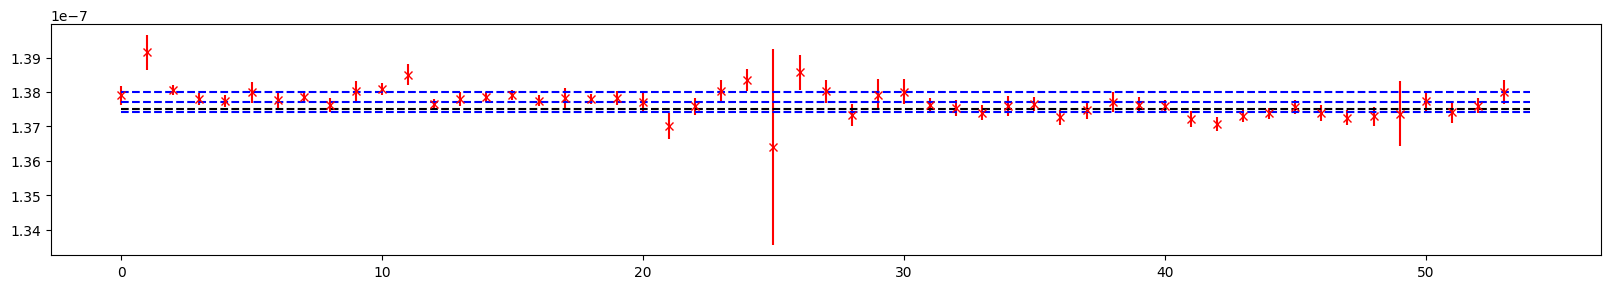

tensor(1.375156769087e-07, dtype=torch.float64)
tensor(1.376981622115e-07, dtype=torch.float64)
tensor(2.908809058972e-10, dtype=torch.float64)



In [17]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_x, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_x)
print(invariant['ix_value'])
print(invariant['ix_error'])
print()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(action_y, 0, 54, linestyles='dashed', color='black')
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, 54, linestyles='dashed', color='blue')
plt.show()

print(action_y)
print(invariant['iy_value'])
print(invariant['iy_error'])
print()

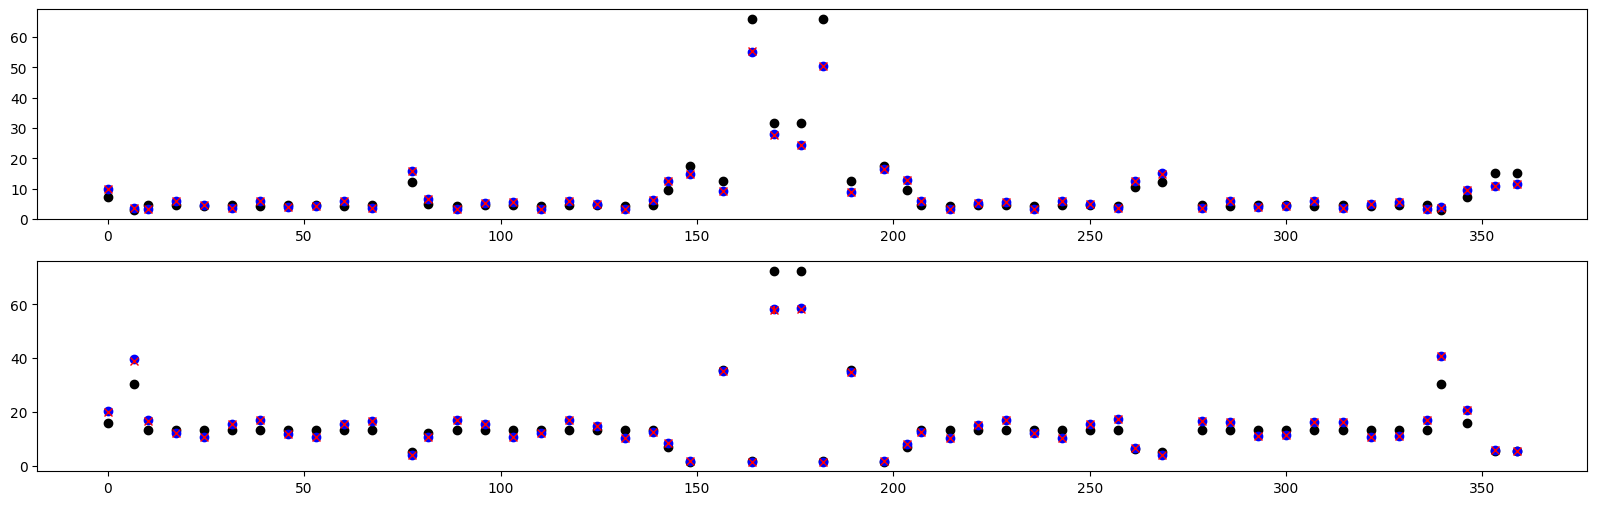

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)
tensor(1.002231996922e+01, dtype=torch.float64)
tensor(1.397734203849e-01, dtype=torch.float64)
tensor(1.381402543473e+00, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)
tensor(8.906506510477e+00, dtype=torch.float64)
tensor(4.010454219395e+00, dtype=torch.float64)
tensor(2.997805972633e+00, dtype=torch.float64)



In [18]:
# Process twiss & compare

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_4 = (cs_bx[model.monitor_index] - value_bx).abs().sum()
error_y_4 = (cs_by[model.monitor_index] - value_by).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print()

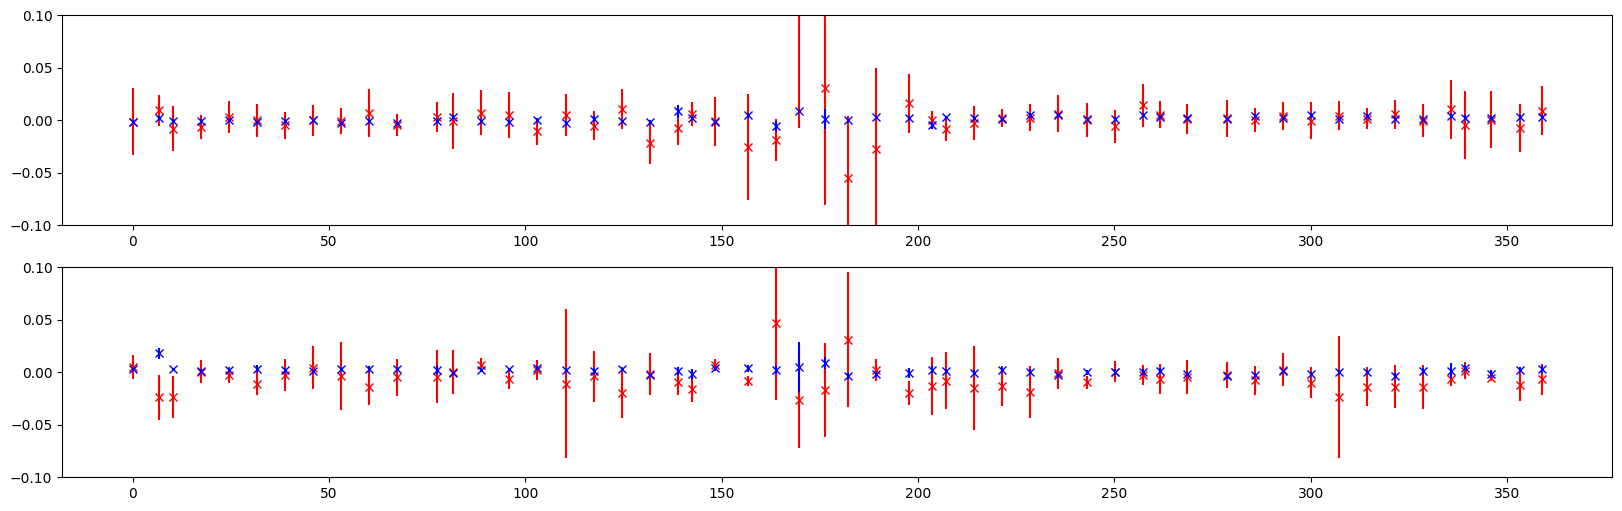

In [19]:
# Plot errors from phase (red) vs fit (blue)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - twiss.bx[model.monitor_index])/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_bx[model.monitor_index]/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - value_bx)/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(error_bx/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

ax = plt.subplot(212)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - twiss.by[model.monitor_index])/cs_by[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_by[model.monitor_index]/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - value_by)/cs_by[model.monitor_index]).cpu().numpy(), yerr=(error_by/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

plt.show()

In [20]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 512 random samples and fixed invariants)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1, 256, parametric_normal, model.matrix, twiss=None, method='pair', limit=1, product=True, jacobian=False, count=512, fraction=0.75, ix=invariant['ix_value'], iy=invariant['iy_value'], n_jobs=12, verbose=False)
print(data.shape)

torch.Size([54, 2, 8, 512])
CPU times: user 1min 7s, sys: 3.04 s, total: 1min 10s
Wall time: 1min 27s


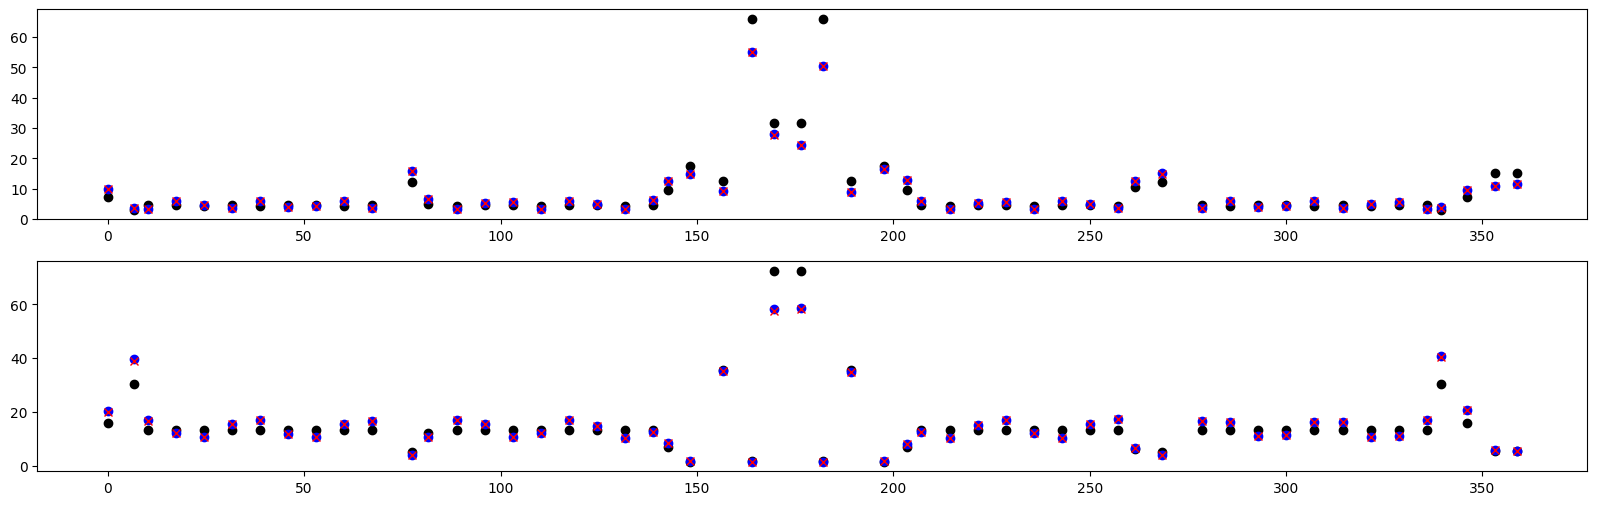

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)
tensor(1.002231996922e+01, dtype=torch.float64)
tensor(1.397734203849e-01, dtype=torch.float64)
tensor(1.381402543473e+00, dtype=torch.float64)
tensor(1.239441730378e+00, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)
tensor(8.906506510477e+00, dtype=torch.float64)
tensor(4.010454219395e+00, dtype=torch.float64)
tensor(2.997805972633e+00, dtype=torch.float64)
tensor(3.489484919758e+00, dtype=torch.float64)



In [21]:
# Process twiss & compare

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_5 = (cs_bx[model.monitor_index] - value_bx).abs().sum()
error_y_5 = (cs_by[model.monitor_index] - value_by).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print(error_x_5)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print(error_y_5)
print()

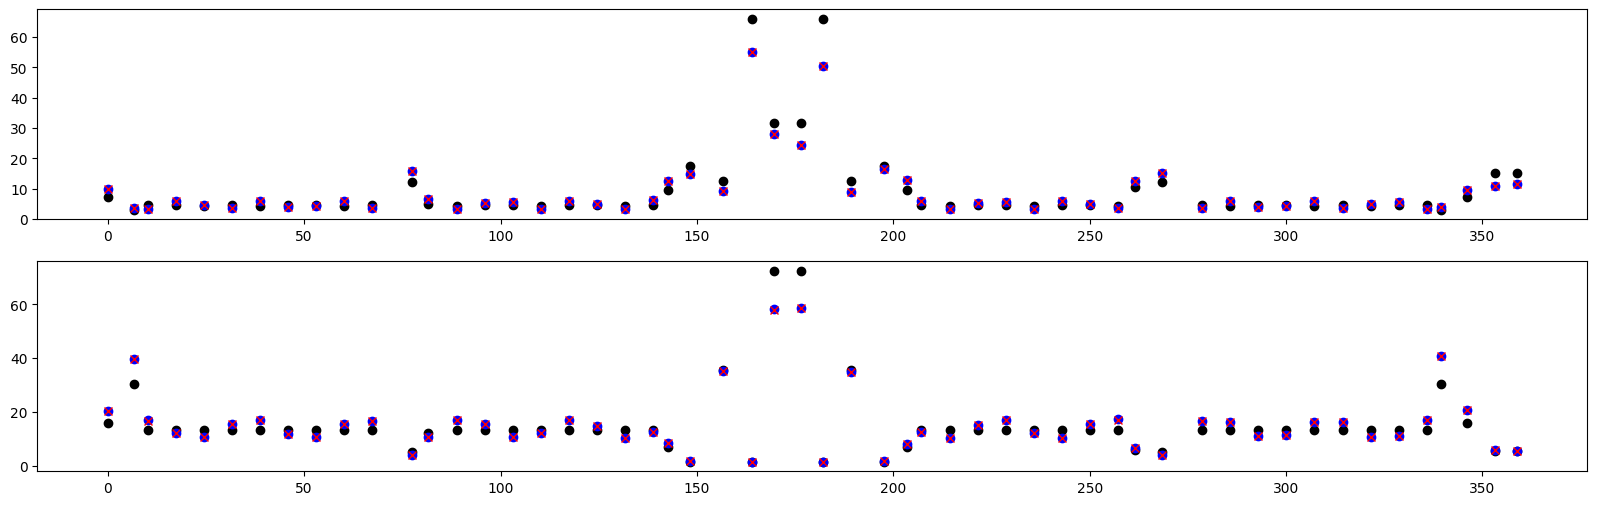

tensor(1.115402971764e+02, dtype=torch.float64)
tensor(7.832071200062e+01, dtype=torch.float64)
tensor(1.002231996922e+01, dtype=torch.float64)
tensor(1.397734203849e-01, dtype=torch.float64)
tensor(1.381402543473e+00, dtype=torch.float64)
tensor(1.239441730378e+00, dtype=torch.float64)
tensor(6.555732494175e-01, dtype=torch.float64)

tensor(1.520498602253e+02, dtype=torch.float64)
tensor(2.267908994054e+01, dtype=torch.float64)
tensor(8.906506510477e+00, dtype=torch.float64)
tensor(4.010454219395e+00, dtype=torch.float64)
tensor(2.997805972633e+00, dtype=torch.float64)
tensor(3.489484919758e+00, dtype=torch.float64)
tensor(1.061134051531e+00, dtype=torch.float64)



In [22]:
# Estimate twiss from amplitude (fixed action)

twiss.get_action(jx=invariant['ix_center'], jy=invariant['iy_center'], sigma_jx=invariant['ix_spread'], sigma_jy=invariant['iy_spread'])
twiss.get_twiss_from_amplitude()

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

error_x_6 = (cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum()
error_y_6 = (cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum()

print(error_x)
print(error_x_1)
print(error_x_2)
print(error_x_3)
print(error_x_4)
print(error_x_5)
print(error_x_6)
print()

print(error_y)
print(error_y_1)
print(error_y_2)
print(error_y_3)
print(error_y_4)
print(error_y_5)
print(error_y_6)
print()

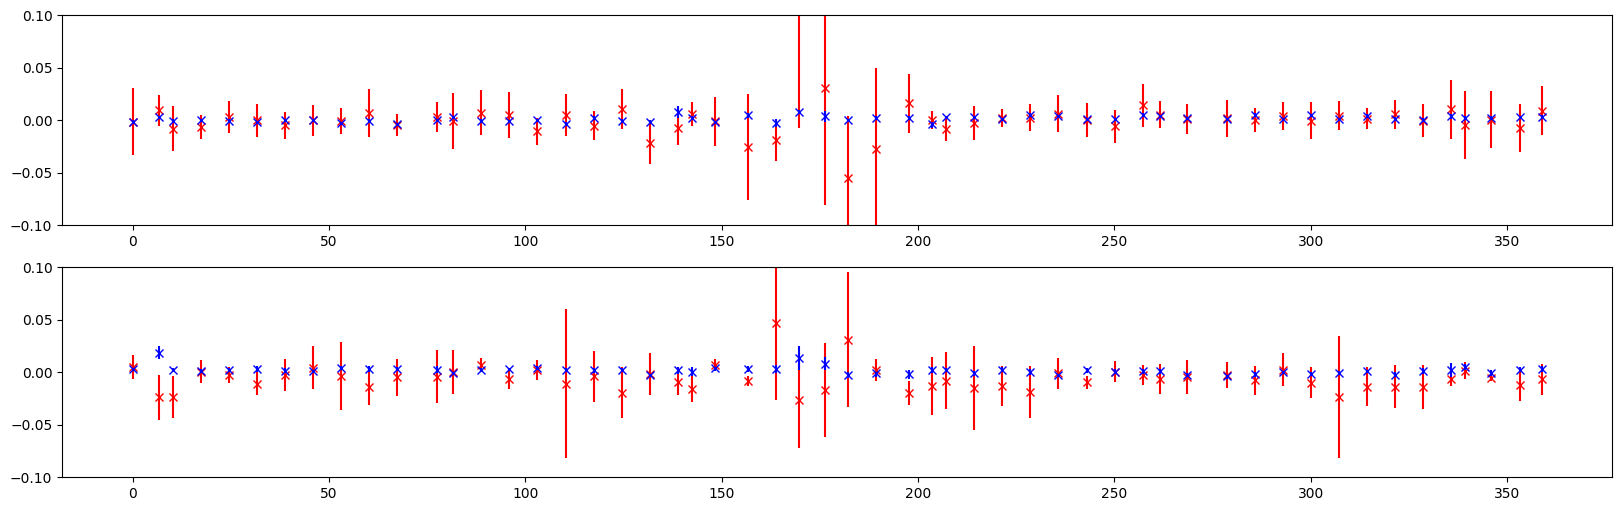

In [23]:
# Plot errors from phase (red) vs fit (blue)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - twiss.bx[model.monitor_index])/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_bx[model.monitor_index]/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_bx[model.monitor_index] - value_bx)/cs_bx[model.monitor_index]).cpu().numpy(), yerr=(error_bx/cs_bx[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

ax = plt.subplot(212)
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - twiss.by[model.monitor_index])/cs_by[model.monitor_index]).cpu().numpy(), yerr=(twiss.sigma_by[model.monitor_index]/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), ((cs_by[model.monitor_index] - value_by)/cs_by[model.monitor_index]).cpu().numpy(), yerr=(error_by/cs_by[model.monitor_index]).cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.set_ylim(-1.0E-1, +1.0E-1)

plt.show()

In [24]:
# Compare alpha from phase vs fitted

print((cs_ax[model.monitor_index] - twiss.ax[model.monitor_index]).abs().sum())
print((cs_ax[model.monitor_index] - value_ax).abs().sum())
print()

print((cs_ay[model.monitor_index] - twiss.ay[model.monitor_index]).abs().sum())
print((cs_ay[model.monitor_index] - value_ay).abs().sum())
print()

tensor(3.303569906319e+00, dtype=torch.float64)
tensor(5.387012026570e-01, dtype=torch.float64)

tensor(1.666413643751e+00, dtype=torch.float64)
tensor(1.294282843745e+00, dtype=torch.float64)



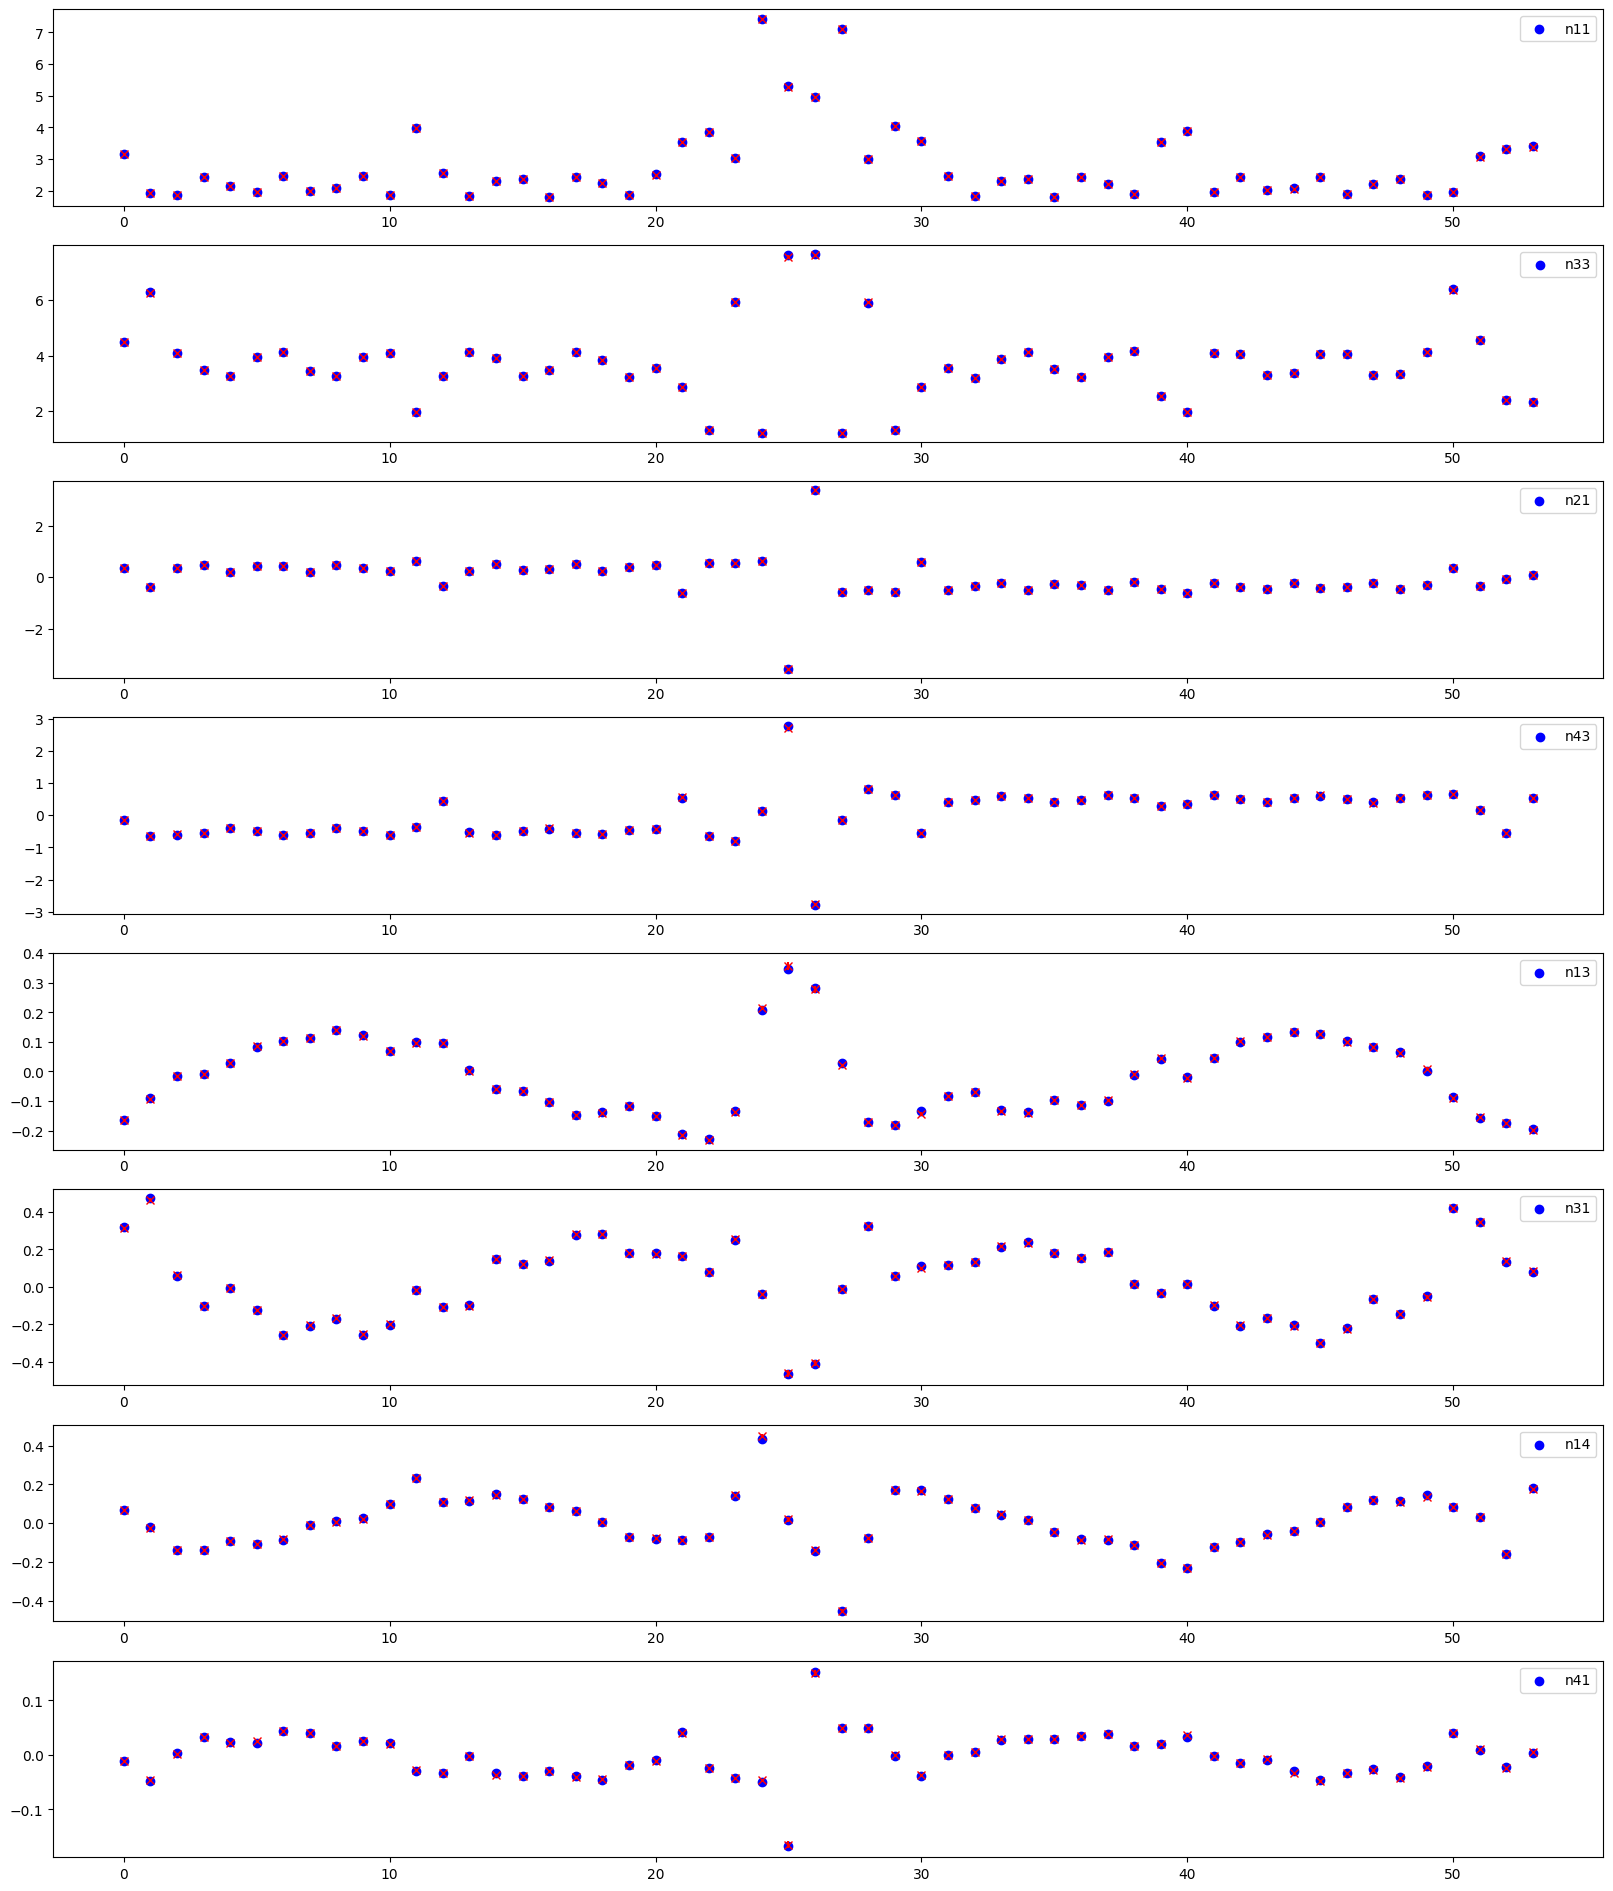

In [25]:
# Compare normalization matrix elements with exact values

plt.figure(figsize=(20, 8*3))

ax = plt.subplot(811)
ax.scatter(range(model.monitor_count), N11, color='blue', marker='o', label='n11')
ax.errorbar(range(model.monitor_count), value_n11, yerr=error_n11, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(812)
ax.scatter(range(model.monitor_count), N33, color='blue', marker='o', label='n33')
ax.errorbar(range(model.monitor_count), value_n33, yerr=error_n33, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(813)
ax.scatter(range(model.monitor_count), N21, color='blue', marker='o', label='n21')
ax.errorbar(range(model.monitor_count), value_n21, yerr=error_n21, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(814)
ax.scatter(range(model.monitor_count), N43, color='blue', marker='o', label='n43')
ax.errorbar(range(model.monitor_count), value_n43, yerr=error_n43, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(815)
ax.scatter(range(model.monitor_count), N13, color='blue', marker='o', label='n13')
ax.errorbar(range(model.monitor_count), value_n13, yerr=error_n13, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(816)
ax.scatter(range(model.monitor_count), N31, color='blue', marker='o', label='n31')
ax.errorbar(range(model.monitor_count), value_n31, yerr=error_n31, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(817)
ax.scatter(range(model.monitor_count), N14, color='blue', marker='o', label='n14')
ax.errorbar(range(model.monitor_count), value_n14, yerr=error_n14, fmt=' ', color='red', marker='x')
ax.legend()

ax = plt.subplot(818)
ax.scatter(range(model.monitor_count), N41, color='blue', marker='o', label='n41')
ax.errorbar(range(model.monitor_count), value_n41, yerr=error_n41, fmt=' ', color='red', marker='x')
ax.legend()

plt.show()

In [26]:
%%time

# Twiss at virtual locations (from virtual orbits)
# Note, method='lstsq'

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256,
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None,
                                 method='lstsq',
                                 limit=2,
                                 phony=True,
                                 product=True,
                                 jacobian=False,
                                 count=512,
                                 fraction=0.75,
                                 ix=invariant['ix_value'],
                                 iy=invariant['iy_value'],
                                 sigma=1.0E-3,
                                 n_jobs=12,
                                 verbose=False)
print(data.shape)
print(model.virtual_count)

torch.Size([5, 2, 8, 512])
5
CPU times: user 6.87 s, sys: 404 ms, total: 7.27 s
Wall time: 9.45 s


In [27]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

In [28]:
# Compare with exact values

numpy.set_printoptions(linewidth=160)

from harmonica.parameterization import cs_normal

for index, location in enumerate(model.virtual_index):
    print(cs_normal(model.ax[location], model.bx[location], model.ay[location], model.by[location])[[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print(torch.stack([value_n11[index], value_n33[index], value_n21[index], value_n43[index], value_n13[index], value_n31[index], value_n14[index], value_n41[index]]).cpu().numpy())
    print(model.out_normal[location][[0, 2, 1, 3, 0, 2, 0, 3], [0, 2, 0, 2, 2, 0, 3, 0]].cpu().numpy())
    print()

[ 2.73266554  3.98175692  0.24822713 -0.16435968  0.          0.          0.          0.        ]
[ 3.16448875  4.46860474  0.33480673 -0.14353106 -0.16666846  0.3162518   0.06485872 -0.0098403 ]
[ 3.15988382  4.49558065  0.33405579 -0.14573133 -0.1624432   0.32044972  0.06574746 -0.00981903]

[ 3.77337285  3.72233085 -0.51812134  0.74143651  0.          0.          0.          0.        ]
[ 4.41159853  4.26304605 -0.62678113  0.85054186 -0.21187941  0.32459902  0.05017719  0.06439459]
[ 4.42893595  4.26077406 -0.62677916  0.84367149 -0.21496507  0.31996092  0.0521124   0.06213687]

[ 8.66226410e-01  2.60206455e-01 -1.96353015e-13 -5.46137670e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
[ 0.97607146  0.29010332 -0.11677334 -0.02354826  0.05567336 -0.01752262 -0.01957044  0.06565894]
[ 0.97586845  0.28882543 -0.1141894  -0.14499197  0.05722246 -0.01805712 -0.01811685  0.06592384]

[ 3.77337285  3.72233085  0.51812134 -0.74143651  0.          0.          0.       